# Notebook 1 — Exploratory Data Analysis & Preprocessing

**Project:** AirSense — Indoor Air Quality Monitoring & ML  
**Dataset:** `data/raw/Air-Quality-Dataset.csv`  
**Author:** AirSense ML Team  
**Date:** 2026-05-18

---

This notebook covers:
1. Dataset loading and initial overview
2. Missing value analysis
3. Univariate distributions
4. Correlation structure
5. Time-series visualisation
6. Class balance (Status + existing category labels)
7. AQI computation (EPA piecewise linear formula)
8. Feature engineering (time, lag, rolling)
9. Train / Validation / Test split
10. Feature scaling & saving processed data

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.data.loader import load_primary

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid', palette='muted')

print('Setup complete. Python', sys.version)

Setup complete. Python 3.14.4 (main, Apr  7 2026, 13:13:20) [Clang 21.0.0 (clang-2100.0.123.102)]


## 1. Dataset Overview

The **Air-Quality-Dataset.csv** was collected by the AirSense IoT sensor network. Key facts:

| Property | Value |
|---|---|
| Rows | 6,199 |
| Sampling interval | ~20 seconds |
| Period covered | January 2023 |
| Separator | semicolon (`;`) |
| Decimal character | comma (`,`) — European format |
| Timezone | UTC (ISO 8601) |

### Sensors

| Column | Unit | Description |
|---|---|---|
| `TIME` | ISO 8601 UTC | Timestamp |
| `CO2` | ppm | Carbon dioxide concentration |
| `PM2,5` (→ `PM25`) | µg/m³ | Fine particulate matter (aerodynamic diameter ≤ 2.5 µm) |
| `PM10` | µg/m³ | Coarse particulate matter (aerodynamic diameter ≤ 10 µm) |
| `TEMPERATURE` | °C | Ambient temperature |
| `HUMIDITY` | % | Relative humidity |
| `CO2 CATEGORY` | categorical | Rule-based CO2 level label |
| `PM2,5 CATEGORY` | categorical | Rule-based PM2.5 label |
| `PM10 CATEGORY` | categorical | Rule-based PM10 label |
| `Status` | binary | 0 = normal, 1 = alert (triggered by high CO2) |

In [2]:
# ── Load primary dataset ──────────────────────────────────────────────────────
try:
    df = load_primary('../data/raw/Air-Quality-Dataset.csv')
    print(f'Loaded {len(df):,} rows, {df.shape[1]} columns')
except FileNotFoundError as e:
    print(f'ERROR: {e}')
    print('Make sure the CSV is at ml/data/raw/Air-Quality-Dataset.csv')
    raise

print('\n--- First 10 rows ---')
df.head(10)

Loaded 6,200 rows, 10 columns

--- First 10 rows ---


,TIME,CO2,PM25,PM10,TEMPERATURE,HUMIDITY,CO2_CAT,PM25_CAT,PM10_CAT,Status
0,2023-01-17 23:15:52+00:00,549,10.0,21.5,17.1,62.30,GOOD,GOOD,GOOD,0
1,2023-01-17 23:16:16+00:00,546,10.0,22.0,17.2,62.31,GOOD,GOOD,GOOD,0
2,2023-01-17 23:16:40+00:00,550,10.0,20.0,17.2,62.32,GOOD,GOOD,GOOD,0
3,2023-01-17 23:17:05+00:00,559,10.0,22.6,16.2,62.33,GOOD,GOOD,GOOD,0
4,2023-01-17 23:17:29+00:00,553,10.0,24.7,13.9,62.34,GOOD,GOOD,GOOD,0
5,2023-01-17 23:17:53+00:00,514,10.0,22.6,12.2,62.35,GOOD,GOOD,GOOD,0
6,2023-01-17 23:18:18+00:00,511,10.0,27.4,11.4,62.36,GOOD,GOOD,GOOD,0
7,2023-01-17 23:18:45+00:00,517,10.0,25.4,11.0,62.37,GOOD,GOOD,GOOD,0
8,2023-01-17 23:19:06+00:00,512,10.0,22.0,12.6,62.38,GOOD,GOOD,GOOD,0
9,2023-01-17 23:19:31+00:00,511,10.0,20.1,13.5,62.39,GOOD,GOOD,GOOD,0


In [3]:
print('--- DataFrame info ---')
df.info()
print('\n--- Descriptive statistics ---')
df.describe(include='all').T

--- DataFrame info ---
<class 'pandas.DataFrame'>
RangeIndex: 6200 entries, 0 to 6199
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   TIME         6200 non-null   datetime64[us, UTC]
 1   CO2          6200 non-null   int64              
 2   PM25         6200 non-null   float64            
 3   PM10         6200 non-null   float64            
 4   TEMPERATURE  6200 non-null   float64            
 5   HUMIDITY     6200 non-null   float64            
 6   CO2_CAT      6200 non-null   str                
 7   PM25_CAT     6200 non-null   str                
 8   PM10_CAT     6200 non-null   str                
 9   Status       6200 non-null   int64              
dtypes: datetime64[us, UTC](1), float64(4), int64(2), str(3)
memory usage: 560.7 KB

--- Descriptive statistics ---


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
TIME,6200,NaN,NaN,NaN,2023-01-20 07:16:13.948064+00:00,2023-01-17 23:15:52+00:00,2023-01-19 02:27:10.250000+00:00,2023-01-20 06:17:01.500000+00:00,2023-01-21 09:21:11.750000+00:00,2023-01-22 19:06:46+00:00,NaN
CO2,6200.0,NaN,NaN,NaN,431.563871,268.0,378.0,400.0,426.0,3000.0,207.556254
PM25,6200.0,NaN,NaN,NaN,11.954613,-1.0,2.3,5.8,7.6,999.9,44.290316
PM10,6200.0,NaN,NaN,NaN,25.408113,-1.0,5.3,9.9,18.6,1999.9,78.836251
TEMPERATURE,6200.0,NaN,NaN,NaN,15.861242,11.0,15.1,15.9,16.4,21.2,0.94426
HUMIDITY,6200.0,NaN,NaN,NaN,62.391949,62.1,62.240875,62.38095,62.520525,62.999,0.186021
CO2_CAT,6200,3,GOOD,5967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PM25_CAT,6200,4,GOOD,5992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PM10_CAT,6200,4,GOOD,5959,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,6200.0,NaN,NaN,NaN,0.098226,0.0,0.0,0.0,0.0,1.0,0.297644


## 2. Missing Values

No missing values found — dataset is complete.


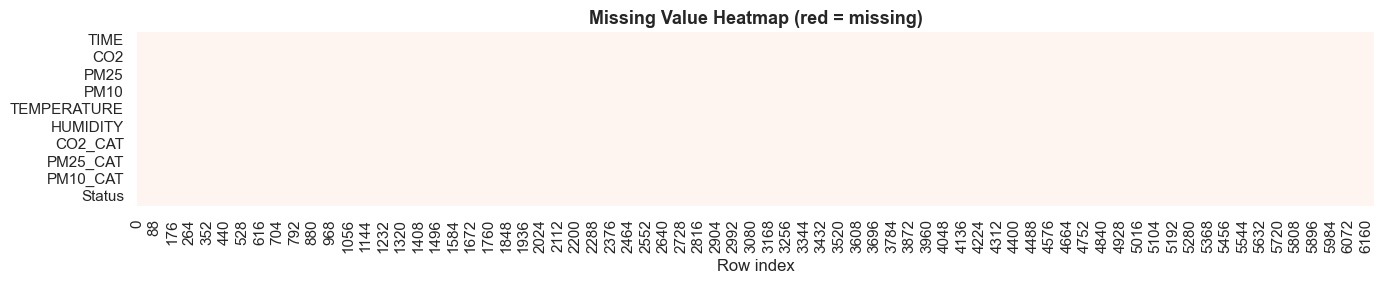

Total missing cells: 0


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percent (%)': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0]

if missing_df.empty:
    print('No missing values found — dataset is complete.')
else:
    print('Columns with missing values:')
    display(missing_df)

# Heatmap of missing values
fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(
    df.isnull().T,
    cbar=False,
    cmap='Reds',
    yticklabels=df.columns,
    ax=ax
)
ax.set_title('Missing Value Heatmap (red = missing)', fontsize=13, fontweight='bold')
ax.set_xlabel('Row index')
plt.tight_layout()
plt.show()
print(f'Total missing cells: {df.isnull().sum().sum()}')

## 3. Distributions

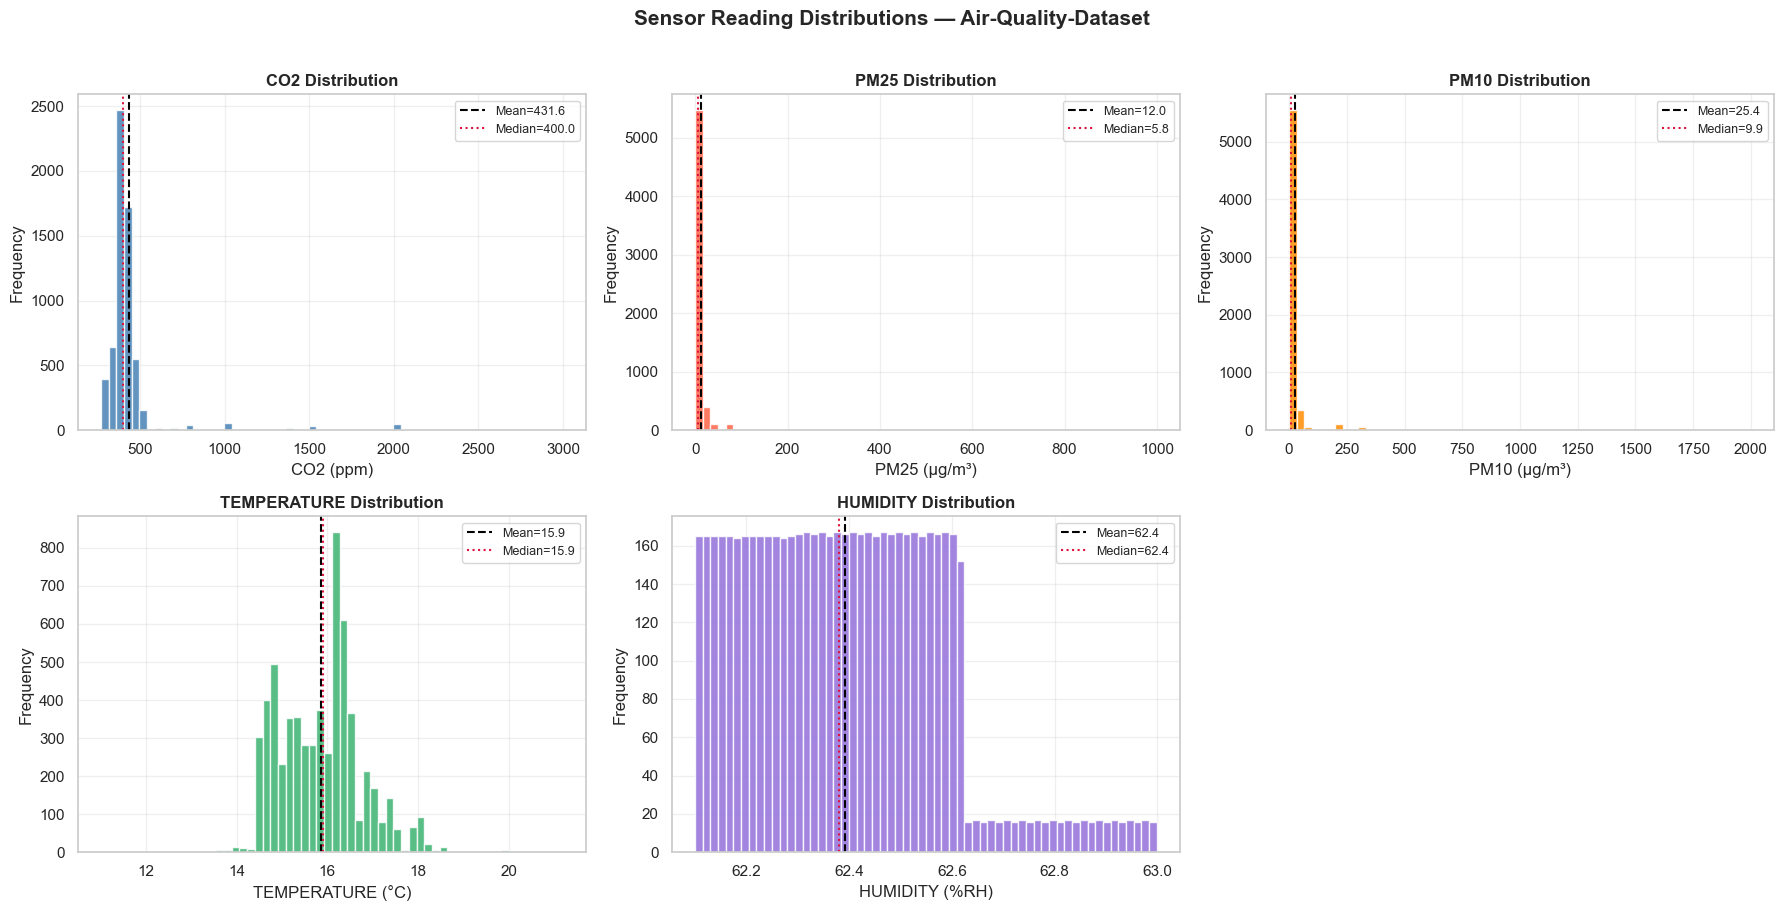


Skewness values:
  CO2: 6.420
  PM25: 13.224
  PM10: 11.581
  TEMPERATURE: 0.621
  HUMIDITY: 0.614


In [5]:
sensor_cols = ['CO2', 'PM25', 'PM10', 'TEMPERATURE', 'HUMIDITY']
units       = ['ppm', 'µg/m³', 'µg/m³', '°C', '%RH']
colors      = ['steelblue', 'tomato', 'darkorange', 'mediumseagreen', 'mediumpurple']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, (col, unit, color) in enumerate(zip(sensor_cols, units, colors)):
    if col not in df.columns:
        axes[i].set_visible(False)
        continue
    axes[i].hist(df[col].dropna(), bins=60, color=color, edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(),   color='black',  linestyle='--', linewidth=1.5, label=f'Mean={df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='crimson', linestyle=':',  linewidth=1.5, label=f'Median={df[col].median():.1f}')
    axes[i].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(f'{col} ({unit})')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

# Hide the 6th subplot (2x3 grid, 5 sensors)
axes[5].set_visible(False)

fig.suptitle('Sensor Reading Distributions — Air-Quality-Dataset', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Summary stats
print('\nSkewness values:')
for col in sensor_cols:
    if col in df.columns:
        print(f'  {col}: {df[col].skew():.3f}')

## 4. Correlation Heatmap

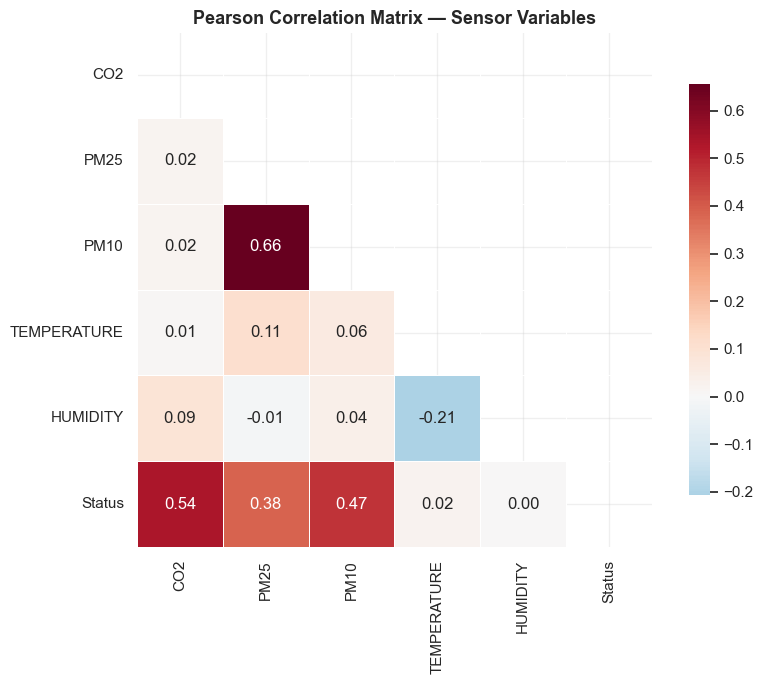

Top 5 positive correlations:
PM10    PM25      0.656331
PM25    PM10      0.656331
Status  CO2       0.537900
CO2     Status    0.537900
Status  PM10      0.474047

Top 5 negative correlations:
Status       HUMIDITY       0.002689
HUMIDITY     PM25          -0.011521
PM25         HUMIDITY      -0.011521
HUMIDITY     TEMPERATURE   -0.207367
TEMPERATURE  HUMIDITY      -0.207367


In [6]:
num_cols = [c for c in sensor_cols + ['Status'] if c in df.columns]
corr_matrix = df[num_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Pearson Correlation Matrix — Sensor Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlations
pairs = corr_matrix.unstack().sort_values(ascending=False)
pairs = pairs[pairs < 1.0]
print('Top 5 positive correlations:')
print(pairs.head(5).to_string())
print('\nTop 5 negative correlations:')
print(pairs.tail(5).to_string())

## 5. Time-Series Plot

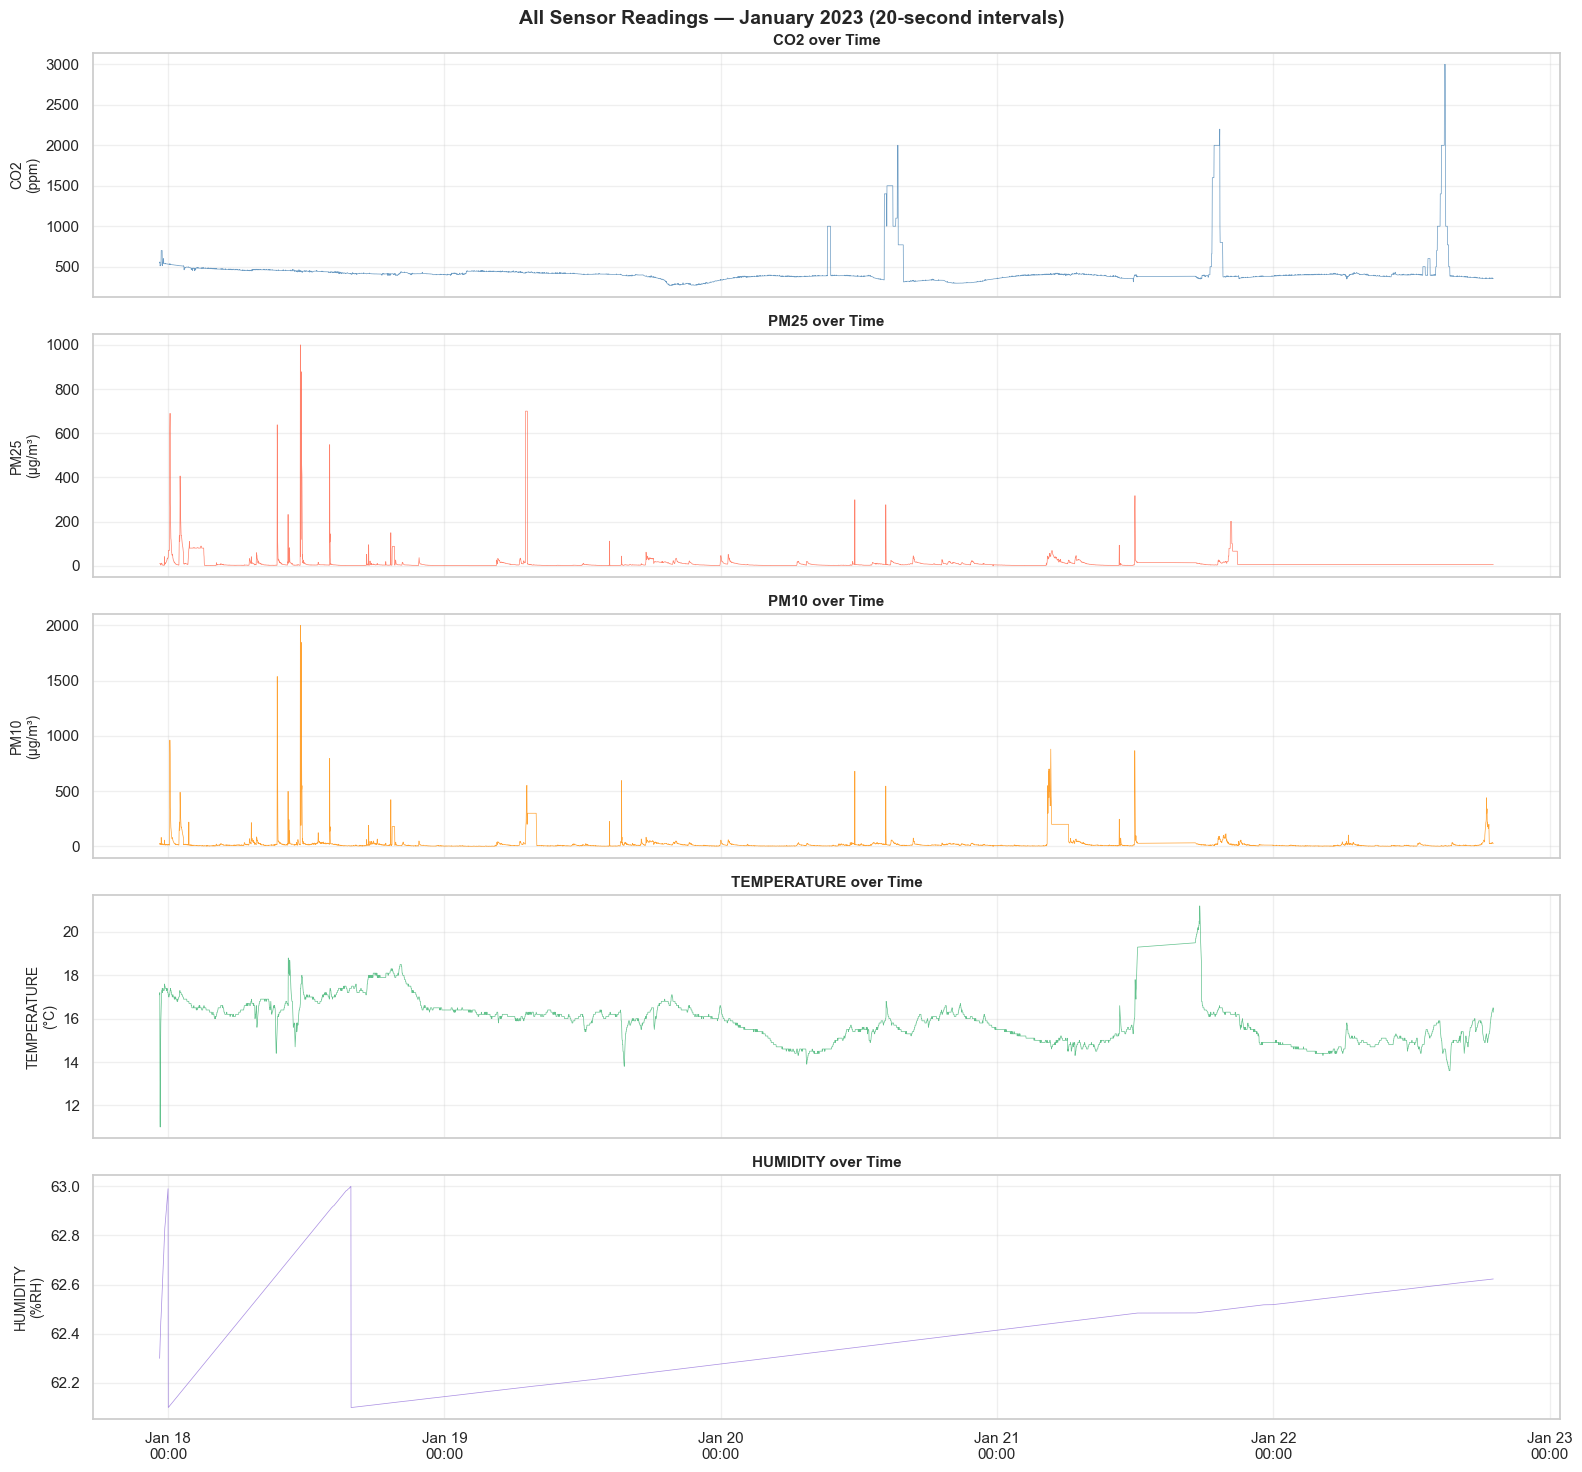

In [7]:
time_col = 'TIME'
plot_sensors = [(c, u, col) for c, u, col in zip(sensor_cols, units, colors) if c in df.columns]
n_plots = len(plot_sensors)

fig, axes = plt.subplots(n_plots, 1, figsize=(16, 3 * n_plots), sharex=True)
if n_plots == 1:
    axes = [axes]

for ax, (col, unit, color) in zip(axes, plot_sensors):
    ax.plot(df[time_col], df[col], linewidth=0.5, color=color, alpha=0.8)
    ax.set_ylabel(f'{col}\n({unit})', fontsize=10)
    ax.set_title(f'{col} over Time', fontsize=11, fontweight='bold')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))
axes[-1].xaxis.set_major_locator(mdates.DayLocator())
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=0)

fig.suptitle('All Sensor Readings — January 2023 (20-second intervals)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Class Balance

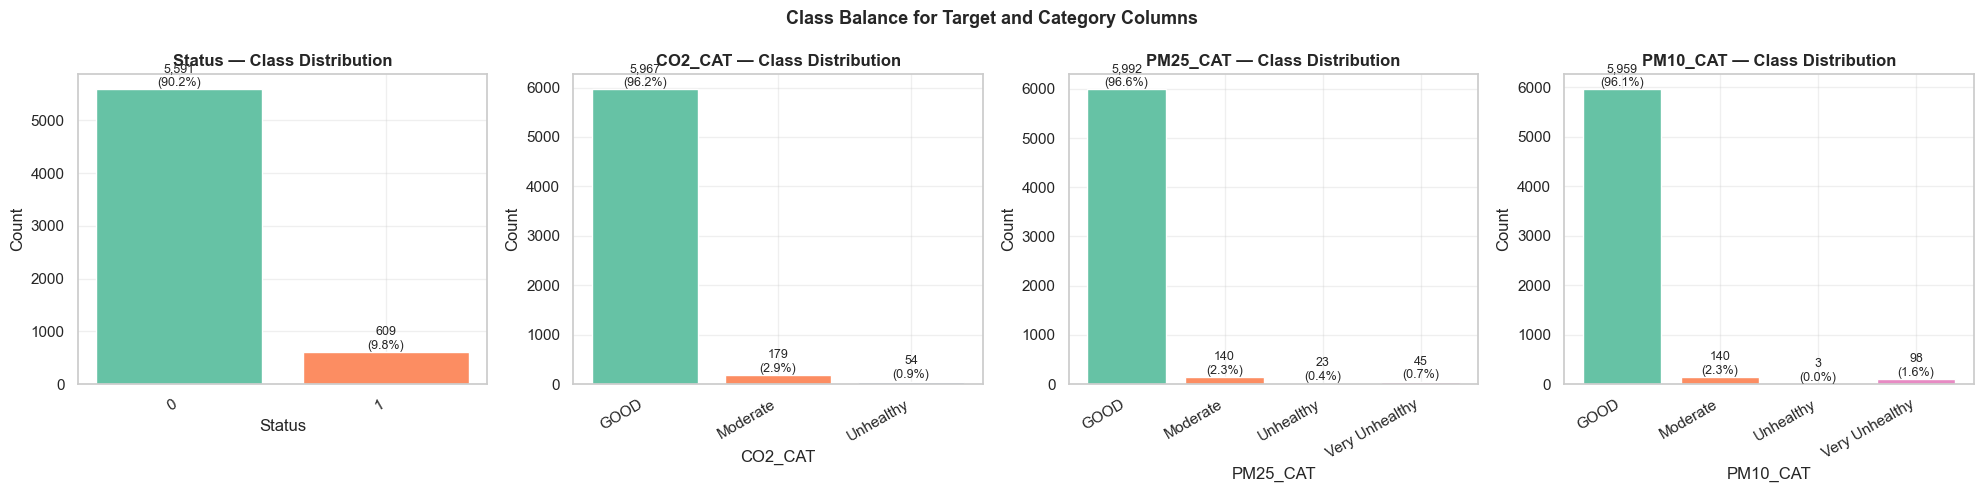


Status imbalance ratio  →  0 (normal): 90.2%  |  1 (alert): 9.8%


In [8]:
cat_cols_present = [c for c in ['Status', 'CO2_CAT', 'PM25_CAT', 'PM10_CAT'] if c in df.columns]
n_cats = len(cat_cols_present)

fig, axes = plt.subplots(1, n_cats, figsize=(5 * n_cats, 5))
if n_cats == 1:
    axes = [axes]

palette = sns.color_palette('Set2', 8)

for ax, col in zip(axes, cat_cols_present):
    vc = df[col].value_counts().sort_index()
    bars = ax.bar(vc.index.astype(str), vc.values, color=palette[:len(vc)], edgecolor='white')
    for bar, val in zip(bars, vc.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9
        )
    ax.set_title(f'{col} — Class Distribution', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle('Class Balance for Target and Category Columns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

if 'Status' in df.columns:
    ratio = df['Status'].value_counts(normalize=True)
    print(f'\nStatus imbalance ratio  →  0 (normal): {ratio.get(0,0):.1%}  |  1 (alert): {ratio.get(1,0):.1%}')

## 7. AQI Computation — EPA Piecewise Linear Formula

The US EPA AQI is computed using a piecewise linear interpolation between concentration breakpoints:

$$AQI = \frac{I_{hi} - I_{lo}}{C_{hi} - C_{lo}} \times (C - C_{lo}) + I_{lo}$$

Where:
- $C$ = pollutant concentration (µg/m³)
- $C_{lo}, C_{hi}$ = lower and upper concentration breakpoints that bracket $C$
- $I_{lo}, I_{hi}$ = corresponding AQI index breakpoints

The **overall AQI** = $\max(AQI_{PM_{2.5}},\, AQI_{PM_{10}})$

### EPA 2024 PM₂.₅ Breakpoints

| AQI Range | PM₂.₅ (µg/m³) | Category |
|-----------|----------------|----------|
| 0–50      | 0.0–9.0        | Good |
| 51–100    | 9.1–35.4       | Moderate |
| 101–150   | 35.5–55.4      | Unhealthy for Sensitive Groups |
| 151–200   | 55.5–125.4     | Unhealthy |
| 201–300   | 125.5–225.4    | Very Unhealthy |
| 301–400   | 225.5–325.4    | Hazardous |
| 401–500   | 325.5–500.0    | Very Hazardous |

### EPA PM₁₀ Breakpoints

| AQI Range | PM₁₀ (µg/m³) | Category |
|-----------|--------------|----------|
| 0–50      | 0–54         | Good |
| 51–100    | 55–154       | Moderate |
| 101–150   | 155–254      | Unhealthy for Sensitive Groups |
| 151–200   | 255–354      | Unhealthy |
| 201–300   | 355–424      | Very Unhealthy |
| 301–400   | 425–504      | Hazardous |
| 401–500   | 505–604      | Very Hazardous |

AQI columns added: ['AQI_PM25', 'AQI_PM10', 'AQI', 'AQI_LABEL', 'AQI_IDX']

AQI statistics:
count    6200.00
mean       41.38
std        55.18
min         1.11
25%        12.78
50%        33.89
75%        45.56
max       500.00
Name: AQI, dtype: float64


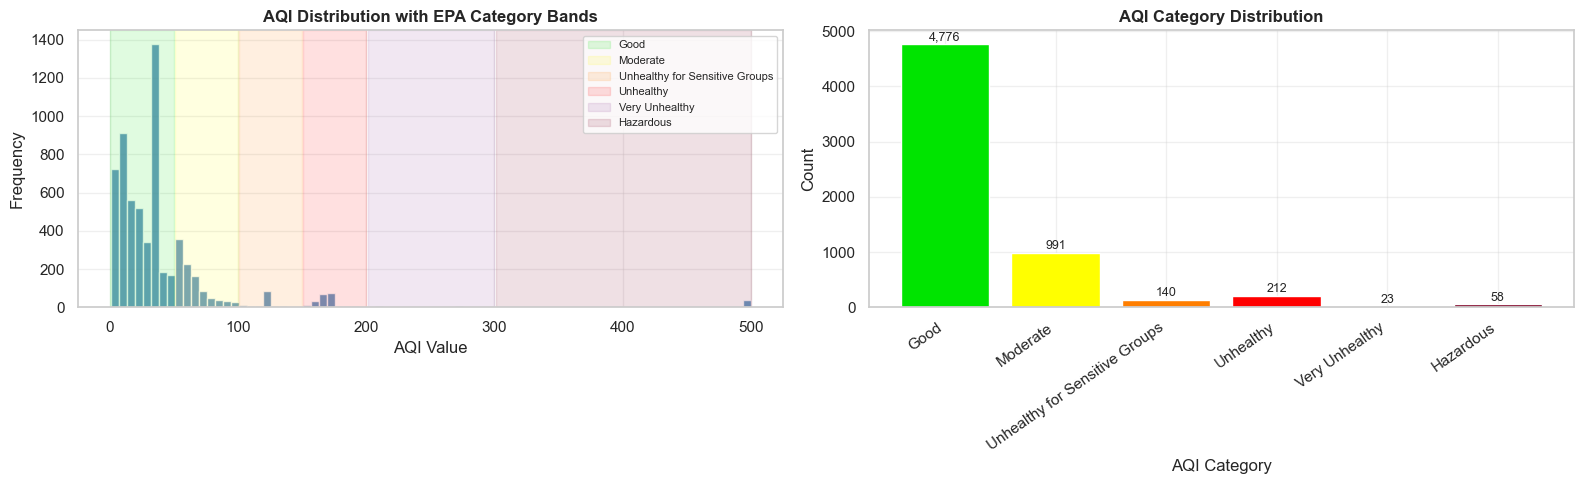

In [9]:
from src.data.preprocessor import add_aqi, AQI_CATEGORIES

df = add_aqi(df)
print('AQI columns added:', [c for c in ['AQI_PM25', 'AQI_PM10', 'AQI', 'AQI_LABEL', 'AQI_IDX'] if c in df.columns])
print()
print('AQI statistics:')
print(df['AQI'].describe().round(2))

# AQI distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram with AQI category colour bands
ax = axes[0]
ax.hist(df['AQI'].dropna(), bins=80, color='steelblue', edgecolor='white', alpha=0.8)
for lo, hi, label, color in AQI_CATEGORIES:
    ax.axvspan(lo, hi, alpha=0.12, color=color, label=label)
ax.set_xlabel('AQI Value')
ax.set_ylabel('Frequency')
ax.set_title('AQI Distribution with EPA Category Bands', fontweight='bold')
ax.legend(fontsize=8, loc='upper right')

# AQI category counts
ax2 = axes[1]
if 'AQI_LABEL' in df.columns:
    order = [c[2] for c in AQI_CATEGORIES]
    cat_colors = [c[3] for c in AQI_CATEGORIES]
    vc = df['AQI_LABEL'].value_counts().reindex(order, fill_value=0)
    bars = ax2.bar(vc.index, vc.values, color=cat_colors, edgecolor='white')
    for bar, val in zip(bars, vc.values):
        if val > 0:
            ax2.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 5,
                f'{val:,}', ha='center', va='bottom', fontsize=9
            )
    ax2.set_xlabel('AQI Category')
    ax2.set_ylabel('Count')
    ax2.set_title('AQI Category Distribution', fontweight='bold')
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=35, ha='right')

plt.tight_layout()
plt.show()

## 8. Feature Engineering

We create three groups of derived features:

| Group | Function | Features created |
|---|---|---|
| **Time features** | `add_time_features` | `hour`, `day_of_week`, `month`, `is_weekend`, `hour_sin/cos`, `dow_sin/cos` |
| **Lag features** | `add_lag_features` | `{col}_lag{n}` for lags [1, 2, 6, 12, 24] |
| **Rolling features** | `add_rolling_features` | `{col}_roll{w}_mean`, `{col}_roll{w}_std` for windows [6, 24, 72] |

In [10]:
from src.data.preprocessor import add_time_features, add_lag_features, add_rolling_features, clean, encode_labels

print('Cleaning …')
df = clean(df)
# Re-apply AQI after clean (clean returns a copy)
df = add_aqi(df)

print('Adding time features …')
df = add_time_features(df)

print('Adding lag features (lags: 1, 2, 6, 12, 24) …')
df = add_lag_features(df)

print('Adding rolling features (windows: 6, 24, 72) …')
df = add_rolling_features(df)

print('Encoding categorical labels …')
df, encoders = encode_labels(df)

# Drop rows with NaN introduced by lag/rolling
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'\nDataFrame after feature engineering: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'New columns ({df.shape[1] - 10} added):')
new_cols = [c for c in df.columns if c not in ['TIME','CO2','PM25','PM10','TEMPERATURE','HUMIDITY','CO2_CAT','PM25_CAT','PM10_CAT','Status']]
for i, c in enumerate(new_cols):
    print(f'  {c}', end='\n' if (i+1) % 5 == 0 else '  ')
print()

Cleaning …
Adding time features …
Adding lag features (lags: 1, 2, 6, 12, 24) …
Adding rolling features (windows: 6, 24, 72) …
Encoding categorical labels …

DataFrame after feature engineering: 6,176 rows x 82 columns
New columns (72 added):
  AQI_PM25    AQI_PM10    AQI    AQI_LABEL    AQI_IDX
  hour    day_of_week    month    is_weekend    hour_sin
  hour_cos    dow_sin    dow_cos    PM25_lag1    PM25_lag2
  PM25_lag6    PM25_lag12    PM25_lag24    PM10_lag1    PM10_lag2
  PM10_lag6    PM10_lag12    PM10_lag24    CO2_lag1    CO2_lag2
  CO2_lag6    CO2_lag12    CO2_lag24    TEMPERATURE_lag1    TEMPERATURE_lag2
  TEMPERATURE_lag6    TEMPERATURE_lag12    TEMPERATURE_lag24    HUMIDITY_lag1    HUMIDITY_lag2
  HUMIDITY_lag6    HUMIDITY_lag12    HUMIDITY_lag24    PM25_roll6_mean    PM25_roll6_std
  PM25_roll24_mean    PM25_roll24_std    PM25_roll72_mean    PM25_roll72_std    PM10_roll6_mean
  PM10_roll6_std    PM10_roll24_mean    PM10_roll24_std    PM10_roll72_mean    PM10_roll72_std
  CO2

## 9. Train / Validation / Test Split

We use a **chronological (temporal) split** — no shuffling — to prevent data leakage from future into past:

| Split | Proportion | Rows (approx) |
|-------|------------|---------------|
| Train | 70% | ~4,339 |
| Validation | 10% | ~620 |
| Test | 20% | ~1,240 |

Train set  : 4324 rows
Val   set  : 617 rows
Test  set  : 1235 rows
Total      : 6176 rows

Train period: 2023-01-17 23:27:17+00:00 → 2023-01-21 04:04:41+00:00
Val   period: 2023-01-21 04:05:43+00:00 → 2023-01-21 19:57:43+00:00
Test  period: 2023-01-21 19:58:46+00:00 → 2023-01-22 19:06:46+00:00


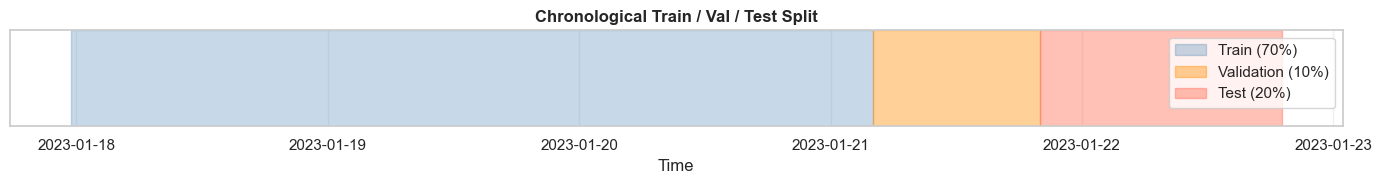

In [11]:
from src.data.preprocessor import split

train, val, test = split(df, test_size=0.20, val_size=0.10)

print('Train set  :', len(train), 'rows')
print('Val   set  :', len(val),   'rows')
print('Test  set  :', len(test),  'rows')
print(f'Total      : {len(train)+len(val)+len(test)} rows')

if 'TIME' in df.columns:
    print(f'\nTrain period: {train["TIME"].min()} → {train["TIME"].max()}')
    print(f'Val   period: {val["TIME"].min()} → {val["TIME"].max()}')
    print(f'Test  period: {test["TIME"].min()} → {test["TIME"].max()}')

# Visualise split on a timeline
fig, ax = plt.subplots(figsize=(14, 2))
if 'TIME' in df.columns:
    ax.axvspan(train['TIME'].min(), train['TIME'].max(), alpha=0.3, color='steelblue', label='Train (70%)')
    ax.axvspan(val['TIME'].min(),   val['TIME'].max(),   alpha=0.4, color='darkorange', label='Validation (10%)')
    ax.axvspan(test['TIME'].min(),  test['TIME'].max(),  alpha=0.4, color='tomato', label='Test (20%)')
    ax.set_xlabel('Time')
    ax.set_yticks([])
    ax.legend(loc='upper right')
    ax.set_title('Chronological Train / Val / Test Split', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Feature Scaling

**StandardScaler** is fitted **only on the training set** and then applied to val and test.  
This is critical: fitting the scaler on all data would leak test-set statistics into training, inflating model performance estimates.

In [12]:
from src.data.preprocessor import scale_features

# Define feature columns: numeric sensor + engineered features (exclude targets & metadata)
exclude = {'TIME', 'CO2_CAT', 'PM25_CAT', 'PM10_CAT', 'AQI_LABEL',
           'AQI_IDX', 'Status', 'CO2_CAT_ENC', 'PM25_CAT_ENC', 'PM10_CAT_ENC',
           'AQI_LABEL_ENC'}
feature_cols = [c for c in train.columns if c not in exclude and train[c].dtype in ['float64','int64','int32']]

print(f'Number of feature columns: {len(feature_cols)}')

train_s, val_s, test_s, scaler = scale_features(train, val, test, feature_cols)

print('\nScaling applied (StandardScaler fitted on train only).')
print(f'Scaler mean[:5]  : {scaler.mean_[:5].round(3)}')
print(f'Scaler scale[:5] : {scaler.scale_[:5].round(3)}')

# Verify train mean ≈ 0
print(f'\nTrain {feature_cols[0]} mean after scaling: {train_s[feature_cols[0]].mean():.4f} (should be ≈ 0)')

Number of feature columns: 71

Scaling applied (StandardScaler fitted on train only).
Scaler mean[:5]  : [418.372  12.451  22.939  16.141  62.333]
Scaler scale[:5] : [143.323  51.445  79.796   0.82    0.191]

Train CO2 mean after scaling: 0.0000 (should be ≈ 0)


In [13]:
import pathlib

processed_path = pathlib.Path('../data/processed/primary_processed.csv')
processed_path.parent.mkdir(parents=True, exist_ok=True)

# Save the full processed dataset (before scaling, so values are interpretable)
df.to_csv(processed_path, index=False)

print(f'Saved processed DataFrame to: {processed_path.resolve()}')
print(f'Shape: {df.shape}')
print(f'File size: {processed_path.stat().st_size / 1024:.1f} KB')

Saved processed DataFrame to: /Users/justinmihigo/Documents/projects/airsense/ml/data/processed/primary_processed.csv
Shape: (6176, 82)
File size: 5269.0 KB


---
## Summary

| Step | Result |
|------|--------|
| Raw rows loaded | 6,199 |
| After cleaning + feature engineering | see above |
| Feature columns created | sensor + time + lag + rolling |
| AQI computed | EPA 2024 piecewise linear formula |
| Split | 70 / 10 / 20 % chronological |
| Scaling | StandardScaler, fitted on train only |
| Processed CSV | `data/processed/primary_processed.csv` |

**Next:** Notebook 02 — Model Comparison (Regression + Classification)